# Analysis: Economic Indicators & Presidential Approval

This notebook explores the relationship between economic variables (CPI, Unemployment, Gas Prices) and Presidential Approval ratings.

## 1. Setup & Data Loading
We fetch data directly from FRED (Economics) and GitHub (Approval Ratings).

In [14]:
import pandas as pd
import pandas_datareader.data as web
import altair as alt
from statsmodels.tsa.stattools import adfuller
import numpy as np
from datetime import datetime

def fetch_economic_data(start_date="1970-01-01"):
    """
    Fetches economic indicators from FRED and resamples to monthly.
    """
    print("Fetching economic data from FRED...")
    # WILL5000PRFC is a good long-term proxy for the S&P 500 on FRED
    series = {
        'CPIAUCSL': 'inflation_cpi',
        'UNRATE': 'unemployment_rate',
        'APU000074714': 'gas_prices',  # US City Avg, Unleaded Regular
        'NASDAQCOM': 'stock_market'    # NASDAQ Composite
    }
    
    end_date = datetime.now().strftime('%Y-%m-%d')
    
    df_list = []
    for code, name in series.items():
        try:
            data = web.DataReader(code, 'fred', start_date, end_date)
            # CRITICAL: Resample to Month Start ('MS') to align disparate frequencies
            data = data.resample('MS').mean()
            data.columns = [name]
            df_list.append(data)
        except Exception as e:
            print(f"Error fetching {code}: {e}")
            
    economics = pd.concat(df_list, axis=1)
    return economics

def fetch_approval_data():
    """
    Fetches historical presidential approval data.
    """
    print("Fetching approval data...")
    url = "https://raw.githubusercontent.com/lorenzo-ruffino/approval_rate_usa_president/main/historical_approval_polls.csv"
    try:
        df = pd.read_csv(url)
        df['date'] = pd.to_datetime(df['poll_end'])
        df = df.set_index('date')
        monthly_approval = df[['approval']].resample('MS').mean()
        monthly_approval.columns = ['approval_rating']
        return monthly_approval
    except Exception as e:
        print(f"Error fetching approval data: {e}")
        return None

# Fetch and Combine Data
econ_df = fetch_economic_data()
approval_df = fetch_approval_data()

if econ_df is not None and approval_df is not None:
    df = econ_df.join(approval_df, how='inner')
    df.index.name = 'date'
    # Apply 3-month rolling average to approval_rating
    df['approval_rating'] = df['approval_rating'].rolling(window=3).mean()
    # Drop NaN values introduced by rolling
    df = df.dropna()
    print("Data loaded successfully.")
    print(df.head())
else:
    print("Failed to load data.")

Fetching economic data from FRED...
Fetching approval data...
Data loaded successfully.
            inflation_cpi  unemployment_rate  gas_prices  stock_market  \
date                                                                     
1976-01-01           55.8                7.9       0.605     83.377143   
1976-02-01           55.9                7.7       0.600     89.302105   
1976-03-01           56.0                7.6       0.594     90.241304   
1976-04-01           56.1                7.7       0.592     90.141429   
1976-05-01           56.4                7.4       0.600     89.291000   

            approval_rating  
date                         
1976-01-01        43.500000  
1976-02-01        44.666667  
1976-03-01        46.833333  
1976-04-01        47.666667  
1976-05-01        48.000000  


## 2. Visual Inspection
Let's look at the raw time series to identify trends and seasonality.

In [15]:
# Melt dataframe for easier Altair plotting
df_long = df.reset_index().melt('date', var_name='indicator', value_name='value')

base = alt.Chart(df_long).mark_line().encode(
    x='date:T',
    y=alt.Y('value:Q', scale=alt.Scale(zero=False)),
    color='indicator:N',
    tooltip=['date', 'indicator', 'value']
).properties(
    width=600,
    height=150
)

chart = base.facet(
    row='indicator:N',
    resolve=alt.Resolve(scale=alt.AxisResolveMap(y=alt.ResolveMode('independent')))
).interactive()

chart

alt.FacetChart(...)

## 3. Stationarity Tests (ADF)
Granger Causality requires stationary time series (constant mean/variance over time). We use the Augmented Dickey-Fuller test.

In [16]:
def adf_test(series, title=''):
    print(f'Augmented Dickey-Fuller Test: {title}')
    if series.nunique() <= 1:
        print(f"Series {title} is constant. Skipping ADF test.\n")
        return
    result = adfuller(series.dropna(), autolag='AIC')
    labels = ['ADF Test Statistic','p-value','# Lags Used','Number of Observations Used']
    out = pd.Series(result[0:4], index=labels)
    for key,val in result[4].items():
        out[f'Critical Value ({key})'] = val
    print(out)
    print('')
    if result[1] <= 0.05:
        print("Strong evidence against the None hypothesis(Ho), reject the None hypothesis. Data has no unit root and is stationary")
    else:
        print("Weak evidence against None hypothesis, time series has a unit root, indicating it is non-stationary ")

for col in df.columns:
    adf_test(df[col], title=col)

Augmented Dickey-Fuller Test: inflation_cpi
ADF Test Statistic               0.766135
p-value                          0.991069
# Lags Used                     12.000000
Number of Observations Used    540.000000
Critical Value (1%)             -3.442518
Critical Value (5%)             -2.866907
Critical Value (10%)            -2.569629
dtype: float64

Weak evidence against None hypothesis, time series has a unit root, indicating it is non-stationary 
Augmented Dickey-Fuller Test: unemployment_rate
ADF Test Statistic              -3.063455
p-value                          0.029379
# Lags Used                      2.000000
Number of Observations Used    550.000000
Critical Value (1%)             -3.442296
Critical Value (5%)             -2.866809
Critical Value (10%)            -2.569576
dtype: float64

Strong evidence against the None hypothesis(Ho), reject the None hypothesis. Data has no unit root and is stationary
Augmented Dickey-Fuller Test: gas_prices
ADF Test Statistic           

## 4. Differencing
Most economic data is non-stationary. We'll take the first difference (t - t-1) to stabilize the mean.

In [17]:
df_diff = df.diff()

print("Running ADF on Differenced Data:")
for col in df_diff.columns:
    adf_test(df_diff[col], title=col)

Running ADF on Differenced Data:
Augmented Dickey-Fuller Test: inflation_cpi
ADF Test Statistic              -4.743666
p-value                          0.000070
# Lags Used                     11.000000
Number of Observations Used    540.000000
Critical Value (1%)             -3.442518
Critical Value (5%)             -2.866907
Critical Value (10%)            -2.569629
dtype: float64

Strong evidence against the None hypothesis(Ho), reject the None hypothesis. Data has no unit root and is stationary
Augmented Dickey-Fuller Test: unemployment_rate
ADF Test Statistic            -1.338670e+01
p-value                        4.857180e-25
# Lags Used                    3.000000e+00
Number of Observations Used    5.480000e+02
Critical Value (1%)           -3.442339e+00
Critical Value (5%)           -2.866829e+00
Critical Value (10%)          -2.569587e+00
dtype: float64

Strong evidence against the None hypothesis(Ho), reject the None hypothesis. Data has no unit root and is stationary
Augment

## 5. Cross-Correlation Analysis
Checking correlations at different lags.

In [18]:
# Example: Cross correlation between Gas Prices and Approval
target = 'approval_rating'
predictor = 'gas_prices'

# Debug: Check data availability
print(f"Correlation Analysis: {predictor} vs {target}")
print(f"N records {predictor}: {df_diff[predictor].count()}")
print(f"N records {target}: {df_diff[target].count()}")

lags = np.arange(-12, 13)
corrs = [df_diff[target].corr(df_diff[predictor].shift(lag)) for lag in lags]

corr_df = pd.DataFrame({'lag': lags, 'correlation': corrs})
print("Correlation results (head):")
print(corr_df.head())

alt.Chart(corr_df.dropna()).mark_bar().encode(
    x='lag:O',
    y='correlation:Q',
    color=alt.condition(
        alt.datum.correlation > 0,
        alt.value('steelblue'),  # The positive color
        alt.value('orange')      # The negative color
    )
).properties(title=f'Cross Correlation: {predictor} vs {target}')

Correlation Analysis: gas_prices vs approval_rating
N records gas_prices: 552
N records approval_rating: 552
Correlation results (head):
   lag  correlation
0  -12    -0.016958
1  -11    -0.025242
2  -10    -0.006795
3   -9    -0.001348
4   -8     0.004142


alt.Chart(...)

In [19]:
# Plotting Correlation with other indicators such as unemployment and approval rating
target = 'approval_rating'
predictor = 'unemployment_rate'


lags = np.arange(-12, 13)
corrs = [df_diff[target].corr(df_diff[predictor].shift(lag)) for lag in lags]
corr_df = pd.DataFrame({'lag': lags, 'correlation': corrs})
alt.Chart(corr_df.dropna()).mark_bar().encode(
    x='lag:O',
    y='correlation:Q',
    color=alt.condition(
        alt.datum.correlation > 0,
        alt.value('steelblue'),  # The positive color
        alt.value('orange')      # The negative color
    ),
    tooltip=[
        alt.Tooltip('lag:O', title='Lag'),
        alt.Tooltip('correlation:Q', title='Correlation')
    ]
).properties(title=f'Cross Correlation: {predictor} vs {target}')

alt.Chart(...)

In [20]:
# Finally checking sp500
target = 'approval_rating'
predictor = 'stock_market'

lags = np.arange(-12, 13)
corrs = [df_diff[target].corr(df_diff[predictor].shift(lag)) for lag in lags]
corr_df = pd.DataFrame({'lag': lags, 'correlation': corrs})
alt.Chart(corr_df.dropna()).mark_bar().encode(
    x='lag:O',
    y='correlation:Q',
    color=alt.condition(
        alt.datum.correlation > 0,
        alt.value('steelblue'),  # The positive color
        alt.value('orange')      # The negative color
    ),
    tooltip=[
        alt.Tooltip('lag:O', title='Lag'),
        alt.Tooltip('correlation:Q', title='Correlation')
    ]
).properties(title=f'Cross Correlation: {predictor} vs {target}')   

alt.Chart(...)

In [21]:
# now cpi
target = 'approval_rating'
predictor = 'inflation_cpi'
lags = np.arange(-12, 13)
corrs = [df_diff[target].corr(df_diff[predictor].shift(lag)) for lag in lags]
corr_df = pd.DataFrame({'lag': lags, 'correlation': corrs})
alt.Chart(corr_df.dropna()).mark_bar().encode(
    x='lag:O',
    y='correlation:Q',
    color=alt.condition(
        alt.datum.correlation > 0,
        alt.value('steelblue'),  # The positive color
        alt.value('orange')      # The negative color
    ),
    tooltip=[
        alt.Tooltip('lag:O', title='Lag'),
        alt.Tooltip('correlation:Q', title='Correlation')
    ]
).properties(title=f'Cross Correlation: {predictor} vs {target}')   

alt.Chart(...)

## Correlation analysis
After a first pass, we see a very irregular situation with the lagged predictors, where for each variable we observe:

- Gas Prices: at the month and upt to 1 month before being asked, its correlated negatively with approval ratings. Interestingly, the positive lag is very negative for a while, suggesting that _after_ the measurement of approval rating, the correlation between the two is even worse.

- Unemployment: Positive correlation up until about a 5 month negative lag, suggesting that when unemployment is high, it actually is positively correlated with aproval in the inmediate future.

- Stock Market: Here its a bit more intuitive, positive impact from -2 to -7, so when people are asked if the stock market was doing goof a couple months ago people might remember that. However this one is a bit more unclear which side the causation goes to, since stock market is so heavly impacted by perception.

## Vector Autoregression (VAR) Analysis
To investigate the dynamic relationships between economic indicators and approval ratings, we will use a Vector Autoregression (VAR) model. This will allow us to analyze how changes in one variable affect others over time and identify potential causal relationships.

In [22]:
from statsmodels.tsa.api import VAR

# Prepare the data for VAR analysis
# Dropping rows with NaN values after differencing
data_for_var = df_diff.dropna()

# Fit the VAR model
model = VAR(data_for_var)
results = model.fit(maxlags=12, ic='aic')  # Automatically select the best lag order using AIC

# Display the summary of the model
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 06, Jan, 2026
Time:                     18:22:31
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                    7.07483
Nobs:                     540.000    HQIC:                   5.59888
Log likelihood:          -4781.87    FPE:                    105.186
AIC:                      4.65088    Det(Omega_mle):         61.5960
--------------------------------------------------------------------
Results for equation inflation_cpi
                           coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------------
const                         0.070974         0.049274            1.440           0.150
L1.inflation_cpi              0.269523         0.070272            3.835           0.000
L1.unemployment_rate

/usr/local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


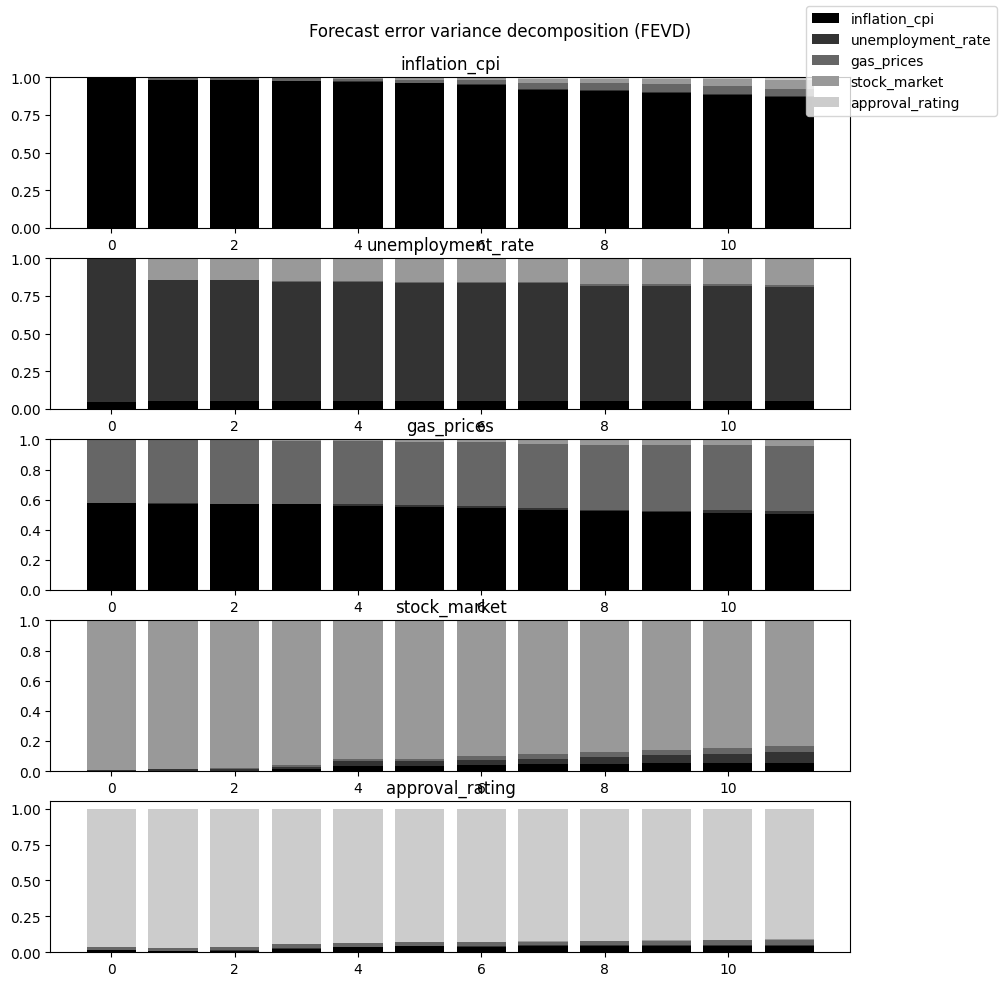

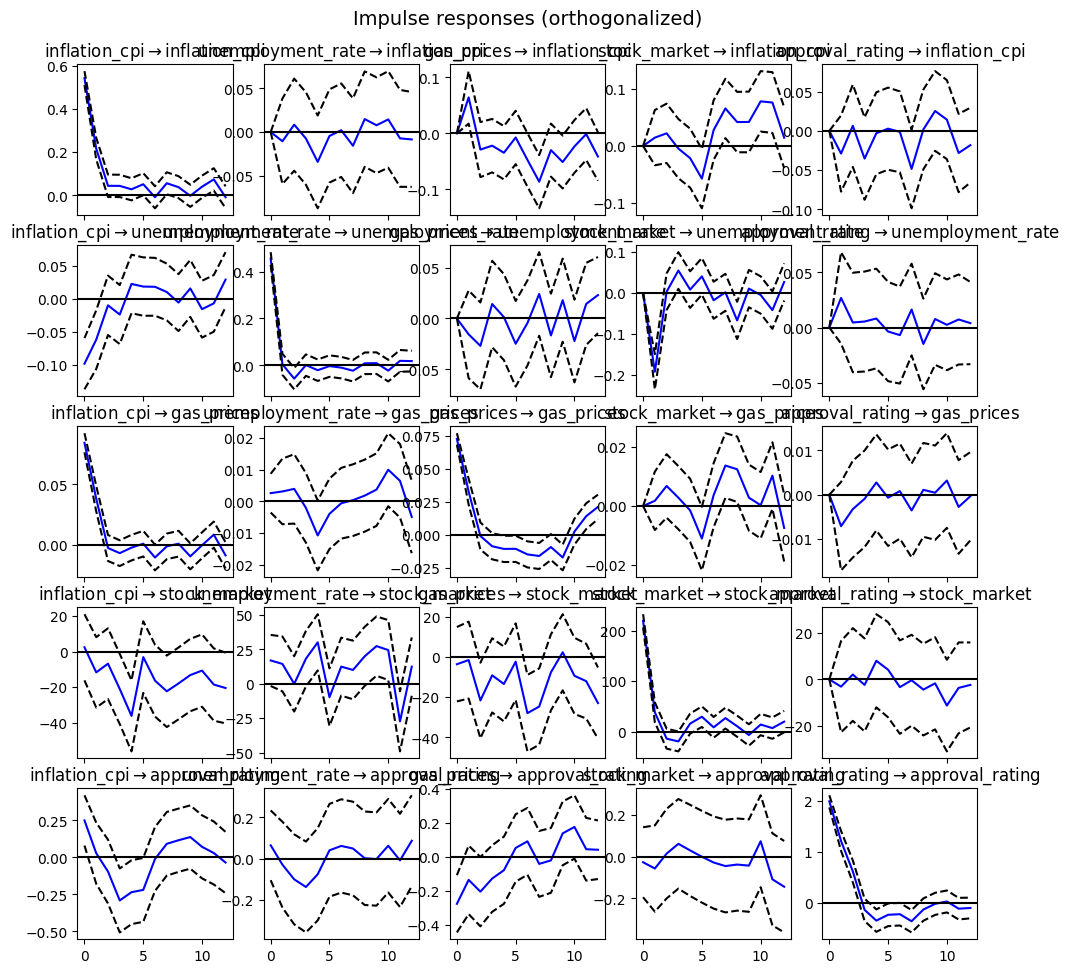

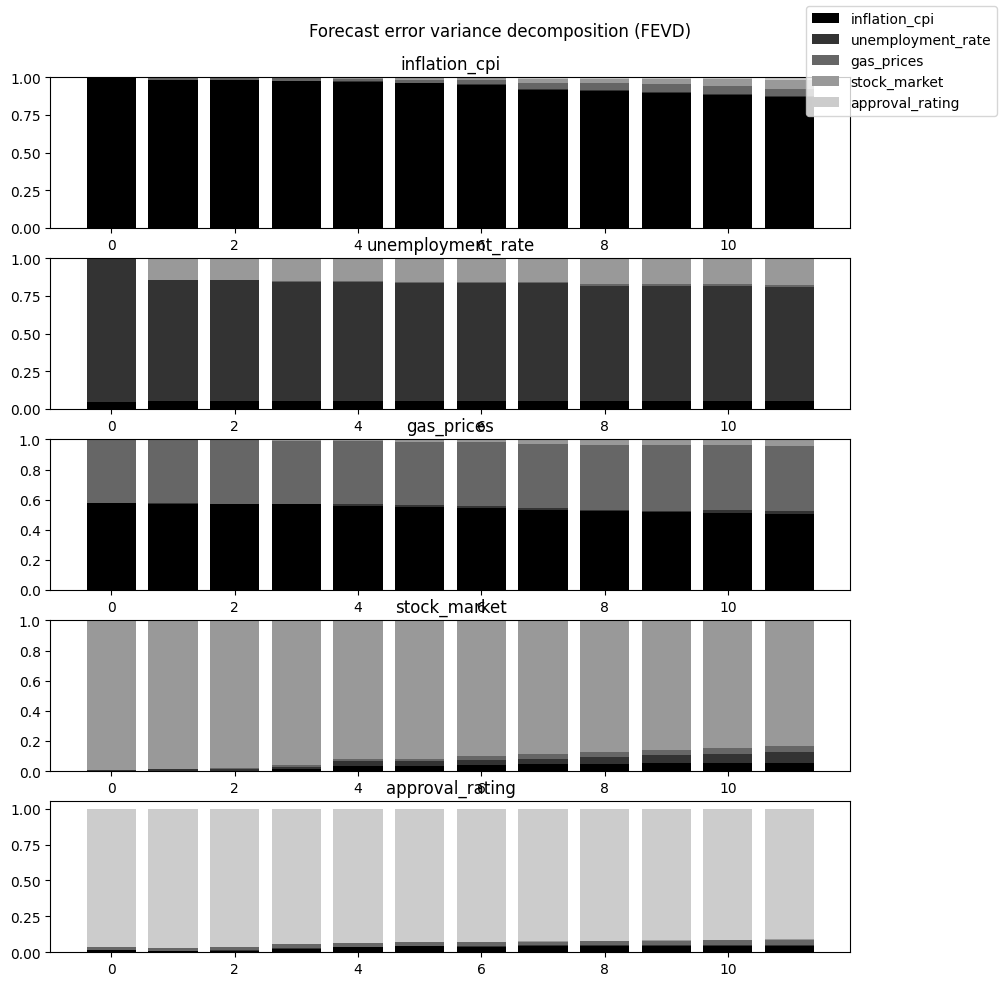

In [23]:
import matplotlib.pyplot as plt
# Impulse Response Analysis
# Analyze the impact of a shock to each variable on the others
irf = results.irf(12)  # Impulse response for 12 periods
irf.plot(orth=True)

# Forecast Error Variance Decomposition
fevd = results.fevd(12)
fevd.plot()

In [24]:
# Granger Causality Tests
# Test if economic indicators Granger-cause approval_rating changes
from statsmodels.tsa.stattools import grangercausalitytests

# Prepare data (differenced and dropped NaNs)
data_granger = df_diff.dropna()

# Max lags for test (can adjust)
max_lags = 12

# Test each predictor against approval_rating
predictors = ['inflation_cpi', 'unemployment_rate', 'gas_prices', 'stock_market']
target = 'approval_rating'

for predictor in predictors:
    print(f"\nGranger Causality Test: {predictor} -> {target}")
    try:
        test_data = data_granger[[target, predictor]]  # Order: [dependent, independent]
        grangercausalitytests(test_data, max_lags, verbose=True)
    except Exception as e:
        print(f"Error testing {predictor}: {e}")

# Interpretation: Look for p-values < 0.05 at any lag; reject null if predictor helps forecast target.


Granger Causality Test: inflation_cpi -> approval_rating

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=6.4885  , p=0.0111  , df_denom=548, df_num=1
ssr based chi2 test:   chi2=6.5241  , p=0.0106  , df=1
likelihood ratio test: chi2=6.4857  , p=0.0109  , df=1
parameter F test:         F=6.4885  , p=0.0111  , df_denom=548, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=4.1345  , p=0.0165  , df_denom=545, df_num=2
ssr based chi2 test:   chi2=8.3449  , p=0.0154  , df=2
likelihood ratio test: chi2=8.2822  , p=0.0159  , df=2
parameter F test:         F=4.1345  , p=0.0165  , df_denom=545, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=3.4599  , p=0.0162  , df_denom=542, df_num=3
ssr based chi2 test:   chi2=10.5136 , p=0.0147  , df=3
likelihood ratio test: chi2=10.4142 , p=0.0154  , df=3
parameter F test:         F=3.4599  , p=0.0162  , df_denom=542, df_num=3

Granger Causality
number of lags (n

/usr/local/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [26]:
# OLS Regression with Lagged CPI (lags 1 to 6)
import statsmodels.api as sm

# Use differenced data for stationarity
data_reg = df_diff.dropna()

# Create lagged inflation_cpi (1 to 6 lags)
for lag in range(1, 7):
    data_reg[f'inflation_cpi_lag_{lag}'] = data_reg['inflation_cpi'].shift(lag)

# Drop rows with NaN from lagging
data_reg = data_reg.dropna()

# Define dependent variable
y = data_reg['approval_rating']

# Define independent variables (lagged inflation_cpi)
X = data_reg[[f'inflation_cpi_lag_{lag}' for lag in range(1, 7)]]
X = sm.add_constant(X)  # Add intercept

# Fit the OLS model
model_ols_lags_cpi = sm.OLS(y, X).fit()

# Print summary
print(model_ols_lags_cpi.summary())

# Interpretation: Check coefficients, p-values, and R-squared. Significant lags indicate predictive power of past inflation_cpi changes on approval_rating changes.

                            OLS Regression Results                            
Dep. Variable:        approval_rating   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     2.609
Date:                Tue, 06 Jan 2026   Prob (F-statistic):             0.0168
Time:                        18:24:48   Log-Likelihood:                -1265.0
No. Observations:                 546   AIC:                             2544.
Df Residuals:                     539   BIC:                             2574.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.2849    

/tmp/ipykernel_89547/2661402094.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_reg[f'inflation_cpi_lag_{lag}'] = data_reg['inflation_cpi'].shift(lag)
/tmp/ipykernel_89547/2661402094.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_reg[f'inflation_cpi_lag_{lag}'] = data_reg['inflation_cpi'].shift(lag)
/tmp/ipykernel_89547/2661402094.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See t

In [25]:
# OLS Regression with Lagged Gas Prices (lags 1 to 6)
import statsmodels.api as sm

# Use differenced data for stationarity
data_reg = df_diff.dropna()

# Create lagged gas_prices (1 to 6 lags)
for lag in range(1, 7):
    data_reg[f'gas_prices_lag_{lag}'] = data_reg['gas_prices'].shift(lag)

# Drop rows with NaN from lagging
data_reg = data_reg.dropna()

# Define dependent variable
y = data_reg['approval_rating']

# Define independent variables (lagged gas_prices)
X = data_reg[[f'gas_prices_lag_{lag}' for lag in range(1, 7)]]
X = sm.add_constant(X)  # Add intercept

# Fit the OLS model
model_ols_lags = sm.OLS(y, X).fit()

# Print summary
print(model_ols_lags.summary())

# Interpretation: Check coefficients, p-values, and R-squared. Significant lags indicate predictive power of past gas_prices changes on approval_rating changes.

                            OLS Regression Results                            
Dep. Variable:        approval_rating   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     3.618
Date:                Tue, 06 Jan 2026   Prob (F-statistic):            0.00158
Time:                        18:22:33   Log-Likelihood:                -1262.0
No. Observations:                 546   AIC:                             2538.
Df Residuals:                     539   BIC:                             2568.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.0239      0.105  

/tmp/ipykernel_89547/597974301.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_reg[f'gas_prices_lag_{lag}'] = data_reg['gas_prices'].shift(lag)
/tmp/ipykernel_89547/597974301.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_reg[f'gas_prices_lag_{lag}'] = data_reg['gas_prices'].shift(lag)
/tmp/ipykernel_89547/597974301.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in t

## Next Steps After OLS Regression on CPI Lags

The OLS model with lagged CPI shows a significant overall F-statistic (p=0.001), indicating that the lagged CPI variables collectively have predictive power for approval_rating changes. However, the R-squared is modest (~0.05), and individual lag coefficients are not highly significant (p-values > 0.05 for most). This suggests multicollinearity among lags or weak individual effects.

Possible directions:
- **Multivariate OLS**: Include multiple economic indicators (e.g., CPI, unemployment, gas prices) with lags to capture combined effects and check for interactions.
- **Feature Selection**: Use stepwise regression or LASSO to select the most relevant lags.
- **Check Assumptions**: Plot residuals for heteroskedasticity, autocorrelation (e.g., Durbin-Watson test), and normality. If violated, consider robust standard errors or GLS.
- **Advanced Models**: Try ARDL (AutoRegressive Distributed Lag) for cointegrated series, or machine learning approaches like random forests for non-linear relationships.
- **Causality Refinement**: Revisit Granger tests with adjusted lags or partial correlations to isolate effects.
- **Data Enhancements**: Explore additional predictors (e.g., GDP, interest rates) or different smoothing windows for approval_rating.
- **Out-of-Sample Testing**: Split data for training/validation to assess predictive accuracy.

Run diagnostics or try multivariate regression next to improve explanatory power.